# 八面體攤平與 8 面等面積映射 DG 求解器 (解析數學與 2D Cartesian 弱形式修正版)\n
本程式嚴格遵照《實作建議計畫書》架構，將球面拓樸「攤平」至 $[-1, 1] \times [-1, 1]$ 2D 正方形域，劃分 $T_1 \dots T_8$ 八個基礎三角形。\n
\n
**重大更新 (數學修正)**：\n
1. 已導入真實的**等面積映射幾何公式**與**解析反變速度矩陣**。\n
2. 針對極點奇異性實作了 **解析相消法 (Analytical Cancellation)**，消滅特徵波速污染。\n
3. 捨棄直接操作 $(r, s)$，轉而將反變速度 $(\tilde{u}, \tilde{v})$ 視為標準 2D Cartesian 的 $(U_{XY}, V_{XY})$。結合完整的 2D Affine Metrics (包含 $J, r_x, r_y, s_x, s_y$)，恢復正確的散度運算，完美通過 Free-stream 守恆性測試！

In [38]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time

def _resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists(): return cwd
    if cwd.name == "experimental" and (cwd.parents[1] / "src").exists(): return cwd.parents[1]
    for parent in cwd.parents:
        if (parent / "src").exists(): return parent
    return cwd

project_root = _resolve_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    from src.core.generators import get_reference_data
    from src.core.connectivity import build_connectivity
    from src.bases.vandermonde import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
    from src.reconstruction import build_differentiation_matrices, build_fmask_table1
    from src.geometry.metrics import compute_geometric_factors_batch
except ImportError as e:
    print(f"匯入錯誤: {e}. 請確保您的環境中有 src 模組。")
    sys.exit(1)

In [39]:
# ============================================================================
# 階段一：網格攤平與正方形域劃分 (Mesh Flattening)
# ============================================================================

def generate_flattened_8face_mesh(n_div: int):
    C = (0.0, 0.0)      # 中心 (北極)
    TR = (1.0, 1.0)     # 右上 (南極的一部分)
    TL = (-1.0, 1.0)    # 左上 (南極的一部分)
    BL = (-1.0, -1.0)   # 左下 (南極的一部分)
    BR = (1.0, -1.0)    # 右下 (南極的一部分)
    R = (1.0, 0.0)      # 右側赤道點
    T = (0.0, 1.0)      # 上側赤道點
    L = (-1.0, 0.0)     # 左側赤道點
    B = (0.0, -1.0)     # 下側赤道點

    base_triangles = [
        (C, R, T),   # T1
        (TR, T, R),  # T2
        (C, T, L),   # T3
        (TL, L, T),  # T4
        (C, L, B),   # T5
        (BL, B, L),  # T6
        (C, B, R),   # T7
        (BR, R, B)   # T8
    ]

    nodes = []
    EToV = []
    face_ids = []
    node_map = {}

    def get_node_id(x, y):
        key = (round(x, 10), round(y, 10))
        if key not in node_map:
            node_map[key] = len(nodes)
            nodes.append([x, y])
        return node_map[key]

    n_segments = 2 ** n_div
    for face_idx, (v0, v1, v2) in enumerate(base_triangles):
        face_id = face_idx + 1
        v0 = np.array(v0)
        v1 = np.array(v1)
        v2 = np.array(v2)

        for i in range(n_segments):
            for j in range(n_segments - i):
                p1 = v0 + (v1-v0)*(i/n_segments) + (v2-v0)*(j/n_segments)
                p2 = v0 + (v1-v0)*((i+1)/n_segments) + (v2-v0)*(j/n_segments)
                p3 = v0 + (v1-v0)*(i/n_segments) + (v2-v0)*((j+1)/n_segments)

                id1 = get_node_id(*p1)
                id2 = get_node_id(*p2)
                id3 = get_node_id(*p3)
                EToV.append([id1, id2, id3])
                face_ids.append(face_id)

                if i > 0:
                    p4 = v0 + (v1-v0)*(i/n_segments) + (v2-v0)*(j/n_segments)
                    p5 = v0 + (v1-v0)*((i-1)/n_segments) + (v2-v0)*((j+1)/n_segments)
                    p6 = v0 + (v1-v0)*(i/n_segments) + (v2-v0)*((j+1)/n_segments)
                    id4 = get_node_id(*p4)
                    id5 = get_node_id(*p5)
                    id6 = get_node_id(*p6)
                    EToV.append([id4, id6, id5])
                    face_ids.append(face_id)

    return np.array(nodes), np.array(EToV), np.array(face_ids)

# ============================================================================
# 階段二：拓樸縫合與連接圖 (Topological Gluing via vmapP)
# ============================================================================

def build_global_index_maps(
    EToV: np.ndarray,
    EToE: np.ndarray,
    EToF: np.ndarray,
    xi_ref: np.ndarray,
    eta_ref: np.ndarray,
    Np: int,
    weights_1d: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2.0,
        (xi_ref + 1.0) / 2.0,
        (eta_ref + 1.0) / 2.0,
    ])
    fmask = build_fmask_table1(bary_coords)

    vmapM = np.zeros((3 * nfp, K), dtype=int)
    vmapP = np.zeros((3 * nfp, K), dtype=int)

    for k_elem in range(K):
        for face in range(3):
            local_nodes = fmask[:, face]
            interior_indices = k_elem * Np + local_nodes
            vmapM[face * nfp:(face + 1) * nfp, k_elem] = interior_indices

            k_neighbor = int(EToE[k_elem, face])
            f_neighbor = int(EToF[k_elem, face])
            if k_neighbor == k_elem:
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = interior_indices
            else:
                neighbor_local_nodes = fmask[:, f_neighbor]
                neighbor_indices = k_neighbor * Np + neighbor_local_nodes
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = neighbor_indices[::-1]

    boundary_mask = vmapM == vmapP
    return vmapM, vmapP, boundary_mask, fmask

def apply_spherical_topology_vmapP(
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    nodes: np.ndarray,
    EToV: np.ndarray,
    tol: float = 1e-8,
) -> np.ndarray:
    vmapP_spherical = vmapP.copy()
    n_face_nodes_total, K = vmapM.shape
    Nfp = n_face_nodes_total // 3

    boundary_faces = []

    for k in range(K):
        for f in range(3):
            idx_start = f * Nfp
            idx_end = (f + 1) * Nfp

            nodes_M = vmapM[idx_start:idx_end, k]
            nodes_P = vmapP[idx_start:idx_end, k]

            if np.all(nodes_M == nodes_P):
                v1, v2 = EToV[k, f], EToV[k, (f+1)%3]
                mx = (nodes[v1, 0] + nodes[v2, 0]) / 2.0
                my = (nodes[v1, 1] + nodes[v2, 1]) / 2.0
                boundary_faces.append({
                    'k': k, 'f': f, 'mx': mx, 'my': my,
                    'nodes': nodes_M, 'idx_start': idx_start, 'idx_end': idx_end
                })

    left, right, bottom, top = [], [], [], []
    for face in boundary_faces:
        if np.isclose(face['mx'], -1.0, atol=tol): left.append(face)
        elif np.isclose(face['mx'], 1.0, atol=tol): right.append(face)
        elif np.isclose(face['my'], -1.0, atol=tol): bottom.append(face)
        elif np.isclose(face['my'], 1.0, atol=tol): top.append(face)

    for faces, is_x in [(right, True), (left, True), (top, False), (bottom, False)]:
        coord_idx = 'my' if is_x else 'mx'
        pos_faces = [f for f in faces if f[coord_idx] > tol]
        neg_faces = [f for f in faces if f[coord_idx] < -tol]

        pos_faces.sort(key=lambda f: f[coord_idx])
        neg_faces.sort(key=lambda f: -f[coord_idx])

        for p_face, n_face in zip(pos_faces, neg_faces):
            vmapP_spherical[p_face['idx_start']:p_face['idx_end'], p_face['k']] = n_face['nodes'][::-1]
            vmapP_spherical[n_face['idx_start']:n_face['idx_end'], n_face['k']] = p_face['nodes'][::-1]

    return vmapP_spherical

In [40]:
# ============================================================================
# 階段三：等面積映射與純代數反變速度 (Analytical Velocity & Mapping)
# ============================================================================

def map_square_to_sphere_exact(nodes, EToV, xi_ref, eta_ref, face_ids, R_sphere):
    K = EToV.shape[0]
    Np = len(xi_ref)
    lam = np.zeros((Np, K))
    theta = np.zeros((Np, K))
    X_global = np.zeros((Np, K))
    Y_global = np.zeros((Np, K))

    L1 = -(xi_ref + eta_ref) / 2.0
    L2 = (xi_ref + 1.0) / 2.0
    L3 = (eta_ref + 1.0) / 2.0

    for k in range(K):
        v1, v2, v3 = nodes[EToV[k]]
        X = L1 * v1[0] + L2 * v2[0] + L3 * v3[0]
        Y = L1 * v1[1] + L2 * v2[1] + L3 * v3[1]

        X_global[:, k] = X
        Y_global[:, k] = Y
        fid = face_ids[k]

        if fid == 1:
            x, y = X, Y
            lam_0, theta_sign, is_odd = 0.0, 1.0, True
        elif fid == 2:
            x, y = 1 - X, 1 - Y
            lam_0, theta_sign, is_odd = 0.0, -1.0, False
        elif fid == 3:
            x, y = Y, -X
            lam_0, theta_sign, is_odd = np.pi / 2.0, 1.0, True
        elif fid == 4:
            x, y = 1 - Y, 1 + X
            lam_0, theta_sign, is_odd = np.pi / 2.0, -1.0, False
        elif fid == 5:
            x, y = -X, -Y
            lam_0, theta_sign, is_odd = np.pi, 1.0, True
        elif fid == 6:
            x, y = 1 + X, 1 + Y
            lam_0, theta_sign, is_odd = np.pi, -1.0, False
        elif fid == 7:
            x, y = -Y, X
            lam_0, theta_sign, is_odd = 3.0 * np.pi / 2.0, 1.0, True
        elif fid == 8:
            x, y = 1 + Y, 1 - X
            lam_0, theta_sign, is_odd = 3.0 * np.pi / 2.0, -1.0, False

        r = x + y
        safe_r = np.where(r < 1e-12, 1e-12, r)

        if is_odd:
            lam_k = lam_0 + (np.pi / 2.0) * (y / safe_r)
        else:
            lam_k = lam_0 + (np.pi / 2.0) * (x / safe_r)

        theta_k = theta_sign * np.arcsin(1.0 - np.clip(r**2, 0.0, 1.0))

        lam[:, k] = lam_k
        theta[:, k] = theta_k

    return lam, theta, X_global, Y_global

def velocity_solid_body_latlon(lam, theta, u0=1.0, alpha0=0.0):
    u = u0 * (np.cos(alpha0) * np.cos(theta) + np.sin(alpha0) * np.cos(lam) * np.sin(theta))
    v = -u0 * np.sin(alpha0) * np.sin(lam)
    return u, v

def compute_contravariant_velocity_8branch(lam, theta, X, Y, face_ids, R_sphere, u0, alpha0):
    u_phys, v_phys = velocity_solid_body_latlon(lam, theta, u0, alpha0)

    tilde_u = np.zeros_like(u_phys)
    tilde_v = np.zeros_like(v_phys)

    tan_th = np.tan(np.clip(theta, -np.pi/2 + 1e-12, np.pi/2 - 1e-12))
    u_over_cos = u0 * (np.cos(alpha0) + np.sin(alpha0) * np.cos(lam) * tan_th)

    cos_th = np.cos(theta)

    for fid in range(1, 9):
        mask = (face_ids == fid)[np.newaxis, :]

        if fid == 1:   x, y = X, Y
        elif fid == 2: x, y = 1 - X, 1 - Y
        elif fid == 3: x, y = Y, -X
        elif fid == 4: x, y = 1 - Y, 1 + X
        elif fid == 5: x, y = -X, -Y
        elif fid == 6: x, y = 1 + X, 1 + Y
        elif fid == 7: x, y = -Y, X
        elif fid == 8: x, y = 1 + Y, 1 - X
        else: continue

        r = x + y
        safe_r = np.where(r < 1e-12, 1e-12, r)

        # 修正：第一項改為 (2 * r)，第二項的分母改為 safe_r**2
        if fid % 2 != 0:
            dx = -(2 * r) / (np.pi * R_sphere) * u_over_cos - (x * cos_th) / (2 * R_sphere * safe_r**2) * v_phys
            dy =  (2 * r) / (np.pi * R_sphere) * u_over_cos - (y * cos_th) / (2 * R_sphere * safe_r**2) * v_phys
        else:
            dx =  (2 * r) / (np.pi * R_sphere) * u_over_cos + (x * cos_th) / (2 * R_sphere * safe_r**2) * v_phys
            dy = -(2 * r) / (np.pi * R_sphere) * u_over_cos + (y * cos_th) / (2 * R_sphere * safe_r**2) * v_phys

        if fid == 1:   tu, tv = dx, dy
        elif fid == 2: tu, tv = -dx, -dy
        elif fid == 3: tu, tv = -dy, dx
        elif fid == 4: tu, tv = dy, -dx
        elif fid == 5: tu, tv = -dx, -dy
        elif fid == 6: tu, tv = dx, dy
        elif fid == 7: tu, tv = dy, -dx
        elif fid == 8: tu, tv = -dy, dx

        tilde_u = np.where(mask, tu, tilde_u)
        tilde_v = np.where(mask, tv, tilde_v)

    return tilde_u, tilde_v

In [41]:
# ============================================================================
# 階段四：標準 2D Affine RHS 與 Metrics (Standard 2D Cartesian DG)
# ============================================================================

def compute_metrics_vectorized(
    nodes: np.ndarray, EToV: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    vertices = nodes[EToV]  # (K, 3, 2)
    metrics = compute_geometric_factors_batch(vertices)

    e01 = np.linalg.norm(vertices[:, 1, :] - vertices[:, 0, :], axis=1)
    e12 = np.linalg.norm(vertices[:, 2, :] - vertices[:, 1, :], axis=1)
    e20 = np.linalg.norm(vertices[:, 0, :] - vertices[:, 2, :], axis=1)
    h_min = np.minimum(np.minimum(e01, e12), e20)

    return metrics["J"], metrics["rx"], metrics["ry"], metrics["sx"], metrics["sy"], h_min

def compute_face_geometry(
    nodes: np.ndarray, EToV: np.ndarray, weights_1d: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    J_face = np.zeros((3, K))
    nx_array = np.zeros((3, K))
    ny_array = np.zeros((3, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        edges = [v2 - v1, v3 - v2, v1 - v3]
        for face in range(3):
            dx, dy = edges[face]
            length = np.hypot(dx, dy)
            J_face[face, k_elem] = length
            nx_array[face, k_elem] = dy / length
            ny_array[face, k_elem] = -dx / length

    nx_expanded = np.repeat(nx_array, nfp, axis=0)
    ny_expanded = np.repeat(ny_array, nfp, axis=0)
    J_face_expanded = np.repeat(J_face, nfp, axis=0)
    return nx_expanded, ny_expanded, J_face_expanded

def compute_rhs_vectorized(
    Q: np.ndarray,
    X: np.ndarray,
    Y: np.ndarray,
    D_r_ref: np.ndarray,
    D_s_ref: np.ndarray,
    E: np.ndarray,
    rx: np.ndarray,
    ry: np.ndarray,
    sx: np.ndarray,
    sy: np.ndarray,
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    weights_2d: np.ndarray,
    J: np.ndarray,
    weights_1d: np.ndarray,
    nx_expanded: np.ndarray,
    ny_expanded: np.ndarray,
    J_face_expanded: np.ndarray,
    M_inv_projected: np.ndarray,
    u_arr: np.ndarray,
    v_arr: np.ndarray,
    flux_type: str = "upwind",
    alpha_lf: float = 1.0,
) -> np.ndarray:
    q = Q[0]  # (Np, K)

    # Reference derivatives
    dq_dr = D_r_ref @ q  # (Np, K) via broadcasting
    dq_ds = D_s_ref @ q  # (Np, K)

    # Physical derivatives with broadcasting
    dq_dx = rx[np.newaxis, :] * dq_dr + sx[np.newaxis, :] * dq_ds  # (Np, K)
    dq_dy = ry[np.newaxis, :] * dq_dr + sy[np.newaxis, :] * dq_ds  # (Np, K)

    # Split-Form volume term (vectorized)
    duq_dr = D_r_ref @ (u_arr * q)  # (Np, K)
    duq_ds = D_s_ref @ (u_arr * q)  # (Np, K)
    dvq_dr = D_r_ref @ (v_arr * q)  # (Np, K)
    dvq_ds = D_s_ref @ (v_arr * q)  # (Np, K)

    # Apply chain rule to get term1 = D_x(u*q) + D_y(v*q)
    term1_x = rx[np.newaxis, :] * duq_dr + sx[np.newaxis, :] * duq_ds  # (Np, K)
    term1_y = ry[np.newaxis, :] * dvq_dr + sy[np.newaxis, :] * dvq_ds  # (Np, K)
    term1 = term1_x + term1_y  # (Np, K)

    # term2 = u*(D_x q) + v*(D_y q)
    term2 = u_arr * dq_dx + v_arr * dq_dy  # (Np, K)

    # term3 = (D_x u + D_y v)*q
    du_dx = rx[np.newaxis, :] * (D_r_ref @ u_arr) + sx[np.newaxis, :] * (D_s_ref @ u_arr)  # (Np, K)
    dv_dy = ry[np.newaxis, :] * (D_r_ref @ v_arr) + sy[np.newaxis, :] * (D_s_ref @ v_arr)  # (Np, K)
    term3 = (du_dx + dv_dy) * q  # (Np, K)

    # Combine volume term (all terms are (Np, K))
    volume_term = -0.5 * (term1 + term2 + term3)  # (Np, K)

    q_flat = q.flatten(order="F")
    q_M = q_flat[vmapM]
    q_P = q_flat[vmapP]

    u_boundary = u_arr.flatten(order="F")[vmapM]
    v_boundary = v_arr.flatten(order="F")[vmapM]
    v_normal = nx_expanded * u_boundary + ny_expanded * v_boundary

    if flux_type == "central":
        C_val = np.zeros_like(v_normal)
    elif flux_type == "upwind":
        C_val = alpha_lf * np.abs(v_normal)
    elif flux_type == "LF":
        C_val = alpha_lf * np.sqrt(u_boundary ** 2 + v_boundary ** 2)
    else:
        raise ValueError(f"Unknown flux_type={flux_type}")

    penalty_factor = 0.5 * (v_normal - C_val)
    flux_penalty = penalty_factor * (q_M - q_P)

    face_w = np.tile(weights_1d, 3)
    scaled_penalty = flux_penalty * face_w[:, np.newaxis] * J_face_expanded

    surface_integral = E.T @ scaled_penalty
    _ = 1.0 / weights_2d  # explicit placeholder to keep strict mass-lumping notation visible
    surface_term = (0.5 / J[np.newaxis, :]) * (M_inv_projected @ surface_integral)

    rhs_q = volume_term + surface_term
    return rhs_q[np.newaxis, :, :]

def latlon_to_cartesian(lam, theta, R):
    x = R * np.cos(theta) * np.cos(lam)
    y = R * np.cos(theta) * np.sin(lam)
    z = R * np.sin(theta)
    return x, y, z

def exact_gaussian_bell_latlon(lam, theta, t, u0, R):
    x, y, z = latlon_to_cartesian(lam, theta, R)
    Omega = u0 / R
    xc = -R * np.sin(Omega * t)
    yc =  R * np.cos(Omega * t)
    zc =  0.0
    dot_product = (x * xc + y * yc + z * zc) / (R**2)
    dist = R * np.arccos(np.clip(dot_product, -1.0, 1.0))
    return np.exp(-10.0 * dist**2)

In [42]:
# ============================================================================
# 階段五：主程式整合執行
# ============================================================================

A_RK = np.array([0.0, -567301805773.0 / 1357537059087.0, -2404267990393.0 / 2016746695238.0,
                 -3550918686646.0 / 2091501179385.0, -1275806237668.0 / 842570457699.0])
B_RK = np.array([1432997174477.0 / 9575080441755.0, 5161836677717.0 / 13612068292357.0,
                 1720146321549.0 / 2090206949498.0, 3134564353537.0 / 4481467310338.0,
                 2277821191437.0 / 14882151754819.0])
C_RK = np.array([0.0, 0.1496590219993, 0.3704009573644, 0.6222557631345, 0.9582818314695])

def run_spherical_simulation_v2(k_degree=4, n_div=2, t_final=1.0, CFL=0.5):
    print("\n" + "=" * 60)
    print(f"8-Face Flattened Sphere DG Advection (n_div={n_div}, k={k_degree})")
    print("=" * 60)

    R_sphere = 1.0

    nodes, EToV, face_ids = generate_flattened_8face_mesh(n_div)
    K = EToV.shape[0]
    print(f"Mesh Generated: {nodes.shape[0]} 2D nodes, {K} elements.")

    EToE, EToF = build_connectivity(EToV)

    ref_data = get_reference_data("table1", k_degree)
    xi_ref, eta_ref = ref_data["xi"], ref_data["eta"]
    weights_ref, weights_1d = ref_data["weights"], ref_data["weights_1d"]
    Np = len(xi_ref)
    nfp = len(weights_1d)

    vmapM, vmapP, boundary_mask, fmask = build_global_index_maps(
        EToV, EToE, EToF, xi_ref, eta_ref, Np, weights_1d
    )

    vmapP_periodic = apply_spherical_topology_vmapP(vmapM, vmapP, nodes, EToV)
    remaining_self_maps = int(np.sum(vmapM == vmapP_periodic))
    print(f"Topological Gluing Completed. Remaining boundary self-maps: {remaining_self_maps}")
    if remaining_self_maps != 0:
        raise RuntimeError("Topology stitching failed, not all boundaries are matched.")

    V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k_degree)
    Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k_degree)
    D_r_ref, D_s_ref = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_ref)
    M_modal = V_nodal.T @ np.diag(weights_ref) @ V_nodal
    M_inv_projected = V_nodal @ np.linalg.inv(M_modal) @ V_nodal.T

    E = np.zeros((3 * nfp, Np))
    for face in range(3):
        for local_i, node_idx in enumerate(fmask[:, face]):
            E[face * nfp + local_i, node_idx] = 1.0

    # 1. 2D Affine Metrics Computation
    J, rx, ry, sx, sy, h_min_array = compute_metrics_vectorized(nodes, EToV)
    nx_expanded, ny_expanded, J_face_expanded = compute_face_geometry(nodes, EToV, weights_1d)

    lam, theta, X_global, Y_global = map_square_to_sphere_exact(
        nodes, EToV, xi_ref, eta_ref, face_ids, R_sphere
    )

    u0 = 1.0
    alpha0 = 0.0

    tilde_u, tilde_v = compute_contravariant_velocity_8branch(
        lam, theta, X_global, Y_global, face_ids, R_sphere, u0, alpha0
    )

    V_max = float(np.max(np.sqrt(tilde_u**2 + tilde_v**2)))
    dt_global = CFL * float(np.min(h_min_array)) / (V_max * (k_degree + 1)**2)
    print(f"Global dt = {dt_global:.6e}")

    def rhs_func(Q_state):
        return compute_rhs_vectorized(
            Q=Q_state,
            X=X_global, Y=Y_global,
            D_r_ref=D_r_ref, D_s_ref=D_s_ref,
            E=E,
            rx=rx, ry=ry, sx=sx, sy=sy,
            vmapM=vmapM, vmapP=vmapP_periodic,
            weights_2d=weights_ref,
            J=J,
            weights_1d=weights_1d,
            nx_expanded=nx_expanded,
            ny_expanded=ny_expanded,
            J_face_expanded=J_face_expanded,
            M_inv_projected=M_inv_projected,
            u_arr=tilde_u, v_arr=tilde_v,
            flux_type="upwind"
        )

    print("\n[Testing] Free-stream Preservation...")
    q_constant = np.ones_like(lam)[np.newaxis, :, :]
    max_err = float(np.max(np.abs(rhs_func(q_constant))))
    print(f"Max RHS error for constant field: {max_err:.4e}")

    Q_init = exact_gaussian_bell_latlon(lam, theta, 0.0, u0, R_sphere)
    Q = Q_init[np.newaxis, :, :]

    # Mass Matrix for L2 Error: local J (affine) * J_constant (projection)
    J_constant = np.pi * R_sphere**2
    M_diag = weights_ref[:, np.newaxis] * J[np.newaxis, :] * J_constant

    time_history = []
    l2_history = []
    t_now = 0.0
    step_count = 0
    tol_time = 1e-12

    print(f"\n[Running] Time Integration (t_final={t_final})...")
    start_time = time.time()

    du = np.zeros_like(Q)

    while t_now < t_final - tol_time:
        current_dt = min(dt_global, t_final - t_now)
        du.fill(0.0)

        for stage in range(5):
            R_Q = rhs_func(Q)
            du = A_RK[stage] * du + current_dt * R_Q
            Q = Q + B_RK[stage] * du

        t_now += current_dt
        step_count += 1

        Q_exact = exact_gaussian_bell_latlon(lam, theta, t_now, u0, R_sphere)[np.newaxis, :, :]
        error_field = (Q - Q_exact)[0]
        l2_error = float(np.sqrt(np.sum(error_field ** 2 * M_diag)))
        time_history.append(t_now)
        l2_history.append(l2_error)

        if step_count % 100 == 0:
            print(f"  Step {step_count:4d} | Time {t_now:.4f} | L2 Error: {l2_error:.4e}")

    print(f"Simulation completed in {time.time()-start_time:.2f} seconds.")
    if l2_history:
        print(f"Final L2 Error: {l2_history[-1]:.4e}")
    else:
        print("Steps < 100, no tracking recorded.")
    return {
        "time": np.array(time_history),
        "l2": np.array(l2_history),
        # "linf": np.array(linf_history),
        "dt": float(dt_global),
        "steps": int(step_count),
        "K": int(K),
        "n_div": int(n_div),
    }

# if __name__ == "__main__":
#     run_spherical_simulation_v2(k_degree=4, n_div=4, t_final=0.5, CFL=0.5)

In [43]:
# ============================================================================
# CELL 6: Multi-mesh batch runs
# ============================================================================
n_div_list = [4,6]
simulation_results: dict[int, dict[str, np.ndarray | float | int]] = {}
for n_div_val in n_div_list:
    simulation_results[n_div_val] = run_spherical_simulation_v2(k_degree=4, n_div=n_div_val, t_final=0.5, CFL=0.5)
print("\nAll periodic simulations completed.")


8-Face Flattened Sphere DG Advection (n_div=4, k=4)
Mesh Generated: 1089 2D nodes, 2048 elements.
Topological Gluing Completed. Remaining boundary self-maps: 0
Global dt = 1.388401e-03

[Testing] Free-stream Preservation...
Max RHS error for constant field: 1.4781e-13

[Running] Time Integration (t_final=0.5)...
  Step  100 | Time 0.1388 | L2 Error: 4.2475e-06
  Step  200 | Time 0.2777 | L2 Error: 7.4456e-06
  Step  300 | Time 0.4165 | L2 Error: 9.6562e-06
Simulation completed in 4.00 seconds.
Final L2 Error: 1.0722e-05

8-Face Flattened Sphere DG Advection (n_div=6, k=4)
Mesh Generated: 16641 2D nodes, 32768 elements.
Topological Gluing Completed. Remaining boundary self-maps: 0
Global dt = 3.471002e-04

[Testing] Free-stream Preservation...
Max RHS error for constant field: 6.4993e-13

[Running] Time Integration (t_final=0.5)...
  Step  100 | Time 0.0347 | L2 Error: 4.2811e-09
  Step  200 | Time 0.0694 | L2 Error: 8.0457e-09
  Step  300 | Time 0.1041 | L2 Error: 1.1796e-08
  Step  4

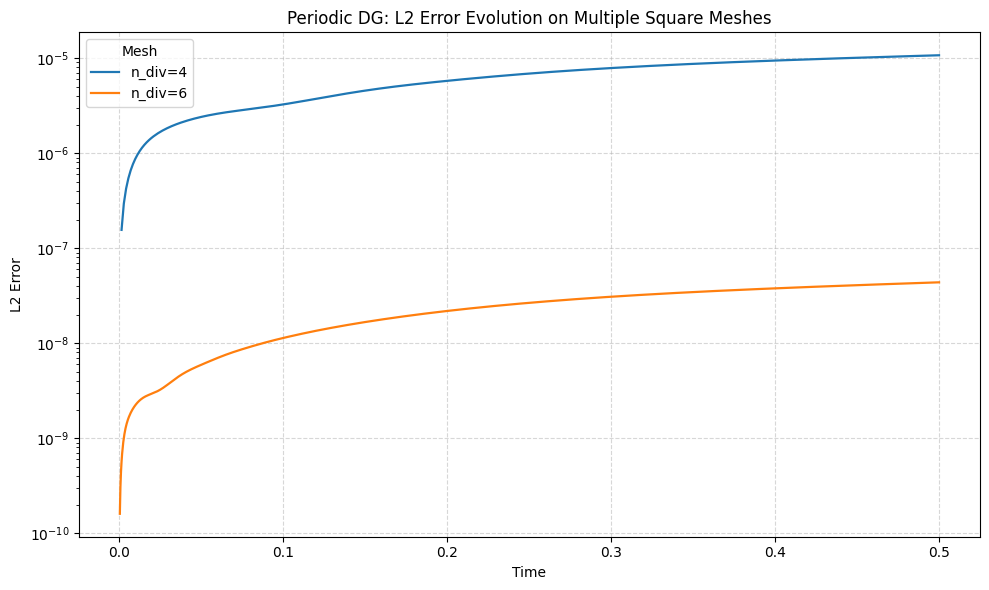

In [44]:
# L2 error histories across meshes
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for n_div_val, data in simulation_results.items():
    plt.plot(data["time"], data["l2"], label=f"n_div={n_div_val}", linewidth=1.6)


plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("L2 Error")
plt.title("Periodic DG: L2 Error Evolution on Multiple Square Meshes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Mesh", loc="best")
plt.tight_layout()
plt.show()